<a href="https://colab.research.google.com/github/asmkushvaha616-ops/titanic-survival-prediction/blob/main/Titanic_Passenger_Survival_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print ("hello world")

hello world


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # titanic dataset is already present in seaborn library


In [14]:
df= sns.load_dataset("titanic")
# load the titanic data from seaborn library

In [15]:
df.head()  # To visualize the data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [16]:
df.shape #info about passanger and column

(891, 15)

In [17]:
df.describe()
# find the statics value of data

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
df.isnull().sum()
# find the null value in the data

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


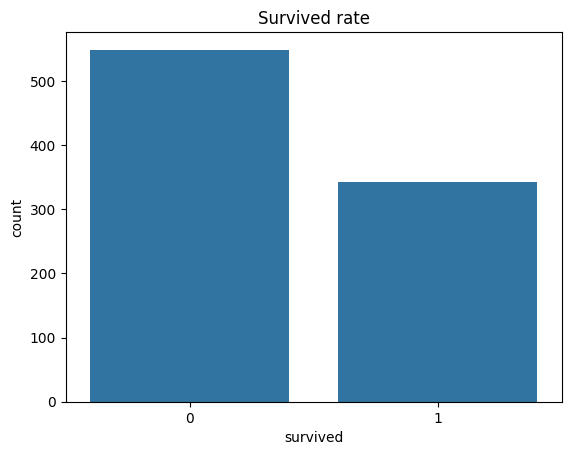

In [20]:
# visualize the data
sns.countplot(data=df,x="survived")
plt.title("Survived rate")
plt.show()

In [22]:
df["survived"].value_counts()

,count
survived,
0,549
1,342


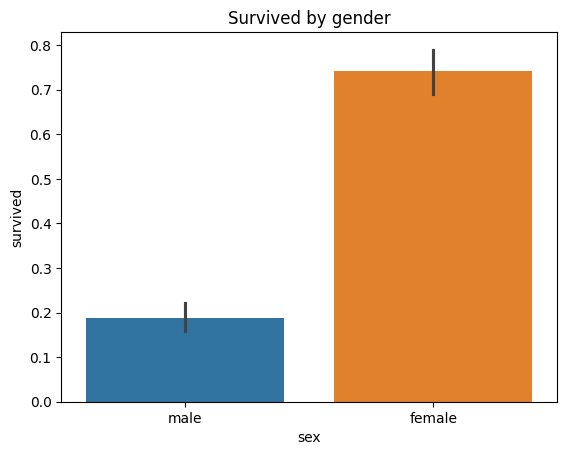

In [25]:
sns.barplot(data=df,x = "sex" , y = "survived" , hue ="sex")
plt.title("Survived by gender")
plt.show()

<Axes: xlabel='pclass', ylabel='survived'>

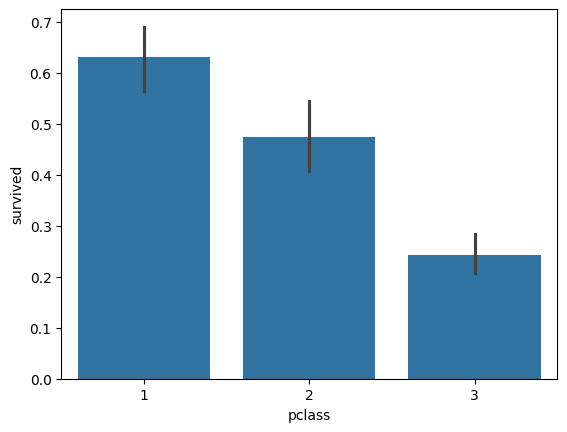

In [29]:
sns.barplot(data=df,x = "pclass" , y = "survived")

In [27]:
df.groupby("pclass")["survived"].value_counts()

pclass  survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [30]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [32]:
df.duplicated().sum()

np.int64(107)

In [34]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [37]:
selected_features = ["sex","age","pclass","fare"]
target = "survived"

df=df.loc[:,selected_features + [target]]
df.head()

,sex,age,pclass,fare,survived
0,male,22.0,3,7.2500,0
1,female,38.0,1,71.2833,1
2,female,26.0,3,7.9250,1
3,female,35.0,1,53.1000,1
4,male,35.0,3,8.0500,0


In [44]:
df["age"] = df["age"].fillna(df["age"].median())
df.head()

,sex,age,pclass,fare,survived
0,0,22.0,3,7.2500,0
1,1,38.0,1,71.2833,1
2,1,26.0,3,7.9250,1
3,1,35.0,1,53.1000,1
4,0,35.0,3,8.0500,0


In [41]:
df.drop_duplicates(inplace=True)

In [42]:
df["sex"]=df["sex"].map({"male":0,"female":1})

In [43]:
df.head()

,sex,age,pclass,fare,survived
0,0,22.0,3,7.2500,0
1,1,38.0,1,71.2833,1
2,1,26.0,3,7.9250,1
3,1,35.0,1,53.1000,1
4,0,35.0,3,8.0500,0


In [46]:
# feature X
# target y
X= df.drop("survived",axis=1)
y = df["survived"]

In [50]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
X_train.shape

(610, 4)

In [52]:
y_train.shape

(610,)

In [53]:
y_test.shape

(153,)

In [54]:
X_test.shape

(153, 4)

In [56]:
y_train.head()

,survived
374,0
840,0
318,1
795,0
97,1


In [57]:
X_train.head()

,sex,age,pclass,fare
374,1,3.0,3,21.0750
840,0,20.0,3,7.9250
318,1,31.0,1,164.8667
795,0,39.0,2,13.0000
97,0,23.0,1,63.3583


In [58]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
# learning
model.fit(X_train,y_train)

LogisticRegression()

In [62]:
X_test.shape

(153, 4)

In [60]:
preds=model.predict(X_test)

In [61]:
preds

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0])

In [63]:
y_test

,survived
397,0
282,0
872,0
209,1
371,0
...,...
63,0
634,0
380,1
360,0


In [64]:
from sklearn.metrics import accuracy_score

In [65]:
accuracy_score(y_test ,preds)

0.7973856209150327

In [72]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

# learning / training
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [73]:
dt_preds=dt_model.predict(X_test)

In [74]:
dt_preds

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0])

In [75]:
y_test

,survived
397,0
282,0
872,0
209,1
371,0
...,...
63,0
634,0
380,1
360,0


In [76]:
accuracy_score(y_test ,dt_preds)

0.6993464052287581